# Import/Settings

In [1]:
# Заставляем ноутбук обновлять импорты автоматически (если ты изменил код в src/)
%load_ext autoreload
%autoreload 2

In [36]:
# 1. Стандартная библиотека
import os
import sys
import warnings
from pathlib import Path

# --- ДИНАМИЧЕСКИЙ РАСЧЕТ АБСОЛЮТНЫХ ПУТЕЙ ---
notebook_dir = Path(os.getcwd()).resolve()
if notebook_dir.name == "notebooks":
    PROJECT_ROOT = notebook_dir.parent
else:
    PROJECT_ROOT = notebook_dir

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 2. Сторонние библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

# 3. Локальные модули
from src.core.data import DevDuckDBDataSource, load_eda_feature_data
from src.core.utils import load_hydra_config

# --- РАБОТА С ПРЕДУПРЕЖДЕНИЯМИ ---
warnings.filterwarnings('ignore', category=FutureWarning)

load_hydra_config.cache_clear()
# --- Инициализация Гидры ---
cfg = load_hydra_config()


run_name = Path(cfg.run_name)
reports_dir = Path(cfg.paths.reports_dir / run_name)
reports_dir.mkdir(parents=True, exist_ok=True)


print(f"Проект: {cfg.project_name} | Режим: EDA")
print(f"Проверка sample_pct: {cfg.data.sample_pct}")

# --- НАСТРОЙКИ ВИЗУАЛИЗАЦИИ ---
try:
    plots_cfg = cfg.logging.plots

    plt.style.use(plots_cfg.style)
    plt.rcParams['figure.figsize'] = plots_cfg.fig_size
    plt.rcParams['figure.dpi'] = plots_cfg.dpi
    plt.rcParams['font.size'] = plots_cfg.font_size
    plt.rcParams['axes.grid'] = plots_cfg.grid
    plt.rcParams['axes.spines.top'] = plots_cfg.spines_top
    plt.rcParams['axes.spines.right'] = plots_cfg.spines_right

    # Сохраним alpha как константу для использования прямо в функциях отрисовки,
    # так как matplotlib не умеет задавать прозрачность глобально
    PLOT_ALPHA = plots_cfg.alpha

    print("Глобальные настройки графиков успешно применены из конфига!")
except AttributeError:
    print("Внимание: Блок logging.plots не найден в конфиге. Используются стандартные графики.")

Проект: credit-risk-model | Режим: EDA
Проверка sample_pct: 0.2
Глобальные настройки графиков успешно применены из конфига!


# DataLoading

In [37]:
# Вся грязная работа (джоины, сэмплирование) скрыта внутри лоадера
loader = DevDuckDBDataSource(cfg, PROJECT_ROOT)
df = loader.load()

print(f"Размер датасета: {df.shape}")
print("-" * 30)
# Быстрый чек глазами: не отвалились ли фичи, правильные ли типы
df.info()

Размер датасета: (395492, 62)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395492 entries, 0 to 395491
Data columns (total 62 columns):
 #   Column                         Non-Null Count   Dtype
---  ------                         --------------   -----
 0   id                             395492 non-null  int64
 1   rn                             395492 non-null  int64
 2   pre_since_opened               395492 non-null  int64
 3   pre_since_confirmed            395492 non-null  int64
 4   pre_pterm                      395492 non-null  int64
 5   pre_fterm                      395492 non-null  int64
 6   pre_till_pclose                395492 non-null  int64
 7   pre_till_fclose                395492 non-null  int64
 8   pre_loans_credit_limit         395492 non-null  int64
 9   pre_loans_next_pay_summ        395492 non-null  int64
 10  pre_loans_outstanding          395492 non-null  int64
 11  pre_loans_total_overdue        395492 non-null  int64
 1

# EDA

## Base Check-Up

In [19]:
# Смотрим, где больше всего дыр в данных
missing = df.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

if not missing.empty:
    print("Топ колонок с пропусками (%):")
    print(missing.head(10))
else:
    print("Пропусков нет! Идеально.")

Пропусков нет! Идеально.


## Targer-Analise

In [43]:
df.head(15)

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,4,1,3,4,1,0,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,4,1,3,4,1,0,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,4,1,2,3,1,1,1,0
3,0,4,4,1,9,12,16,7,12,2,...,3,3,4,1,3,1,1,0,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,4,1,3,4,1,0,0,0
5,0,6,5,0,11,8,12,11,4,2,...,3,3,4,1,2,3,1,0,1,0
6,0,7,3,9,1,2,12,14,15,5,...,3,3,4,1,3,4,1,0,0,0
7,0,8,2,9,2,3,12,14,15,5,...,3,3,4,1,3,4,1,0,0,0
8,0,9,1,9,11,13,14,8,2,5,...,3,3,4,1,2,4,1,0,0,0
9,0,10,7,9,2,10,8,8,16,4,...,3,3,4,1,2,4,1,0,0,0


In [20]:
task_type = cfg.task_type
target_col = cfg.data.tabular.target_col
id_col = cfg.data.tabular.id_col

In [51]:
df.groupby(id_col)['rn'].mean().mean()

np.float64(4.456185979513444)

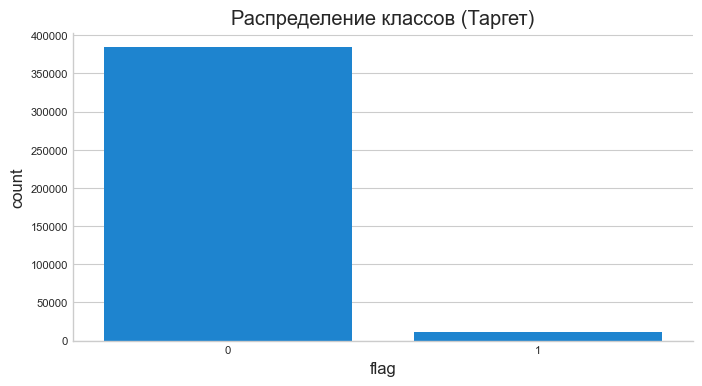

In [21]:
plt.figure(figsize=(8, 4))

if task_type in ['binary', 'multiclass']:
    # Смотрим дисбаланс классов
    sns.countplot(data=df, x=target_col)
    plt.title("Распределение классов (Таргет)")
elif task_type == 'regression':
    # Смотрим распределение (хвосты, выбросы)
    sns.histplot(data=df, x=target_col, kde=True, bins=50)
    plt.title("Распределение целевой переменной (Регрессия)")

plt.show()

In [22]:
df.groupby(id_col)[target_col].max().value_counts(normalize=True)

flag
0    0.96961
1    0.03039
Name: proportion, dtype: float64

## AutoEDA

Особенности данных в том что они являются бинаризированными с случайными наименованиями бинов(то есть зашифрованными)

не бинаризированные фичи ['id', 'rn', 'is_zero_loans_5', 'is_zero_loans_530', 'is_zero_loans_3060', 'is_zero_loans_6090', 'is_zero_loans90', 'is_zero_util', 'is_zero_over2limit', 'is_zero_maxover2limit', 'pclose_flag', 'fclose_flag']

если обобщить не закодированными являются 
- (id, rn) - идентификационные колонки
- (is_zero_*) - булевые фичи
- (pclose, fclose) - флаги дней

In [23]:
exact_excludes = {'id', 'rn', 'pclose_flag', 'fclose_flag'}
    
encrypted_cols = [
    col for col in df.columns 
    if col not in exact_excludes and not col.startswith('is_zero_') and not target_col
]

In [24]:
feature_config = sv.FeatureConfig(force_cat=encrypted_cols)
print("Генерация HTML-отчета через Sweetviz...")

# Запускаем тяжелую артиллерию
report = sv.analyze(df, target_feat=target_col, feat_cfg=feature_config)
output_path = reports_dir / "eda_report.html"
report.show_html(filepath=str(output_path), open_browser=True)

print(f"Отчет сохранен в: {output_path}")

Генерация HTML-отчета через Sweetviz...


                                             |          | [  0%]   00:00 -> (? left)

Report reports\p_v0.0.0__f_v0.0.0__m_v0.0.0\eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Отчет сохранен в: reports\p_v0.0.0__f_v0.0.0__m_v0.0.0\eda_report.html


## Выводы по анализу:

### Типы данных
т.к. 90% фичей это закодированные бины, которые не отражают непрерывность их стоит перевести в категориальные и работать с ними как с категориальным признаками

### Missing Values

Пропусков в Dataframe не обнаружено, т.к. категориальные переменные оставлю заполнение тегом unknown, не модой т.к. отсутствие какого то параметра может быть также быть критерием к потенциальному нарушению

### Доминантные бины в категориях

Не сильно но выделяются: 
- pre_since_confirmed (9 бин) 21% следющий 8.5%
- pre_fterm (8 бин) 23.1% следующий 7.3%
- pre_till_pclose (1 бин) 21.6% следующий 6.3%
- pre_till_fclose (11 бин) 26,7% следующий 6,9%
- pre_loans_credit_cost_rate (4 бин и 2 бин) 31,1% и 20,4% следующий 6,9% 

Сильно выделяются:
- pre_loans_next_pay_summ (2 бин) 63% следующий 7%
- pre_loans_outstanding (3 бин) 80%
- pre_loans_max_overdue_sum (2 бин) 89%
- pre_loans5 (6 бин) 99%
- pre_loans530 (16 бин) 97,7%
- pre_loans3060 (5 бин) 99%
- pre_loans6090 (4 бин) 99%
- pre_loans90 (8 бин) 99%
- pre_util (16 бин) 72%
- pre_over2limit (2 бин) 94,6% 
- pre_maxover2limit (17 бин) 89,2%
- enc_paym_* - Имеется четки тренд того что (0 Бин) имеет на 1 месяце 92% но стабильно снижается заменяясь (3 бином)
- - на 12 месяце (4 бин) = 57% (1 бин) = 40%  (0 бин) вообще отсутствует
- - на 24 месяце (4 бин) = 86% (1 бин) = 14%
- enc_loans_account_holder_type (1 бин) 99%
- enc_loans_credit_status (3 бин) 68% (2 бин) 31%
- enc_loans_credit_type (4 бин) 55% (3 бин) 28% следующий (1 бин) 9% и дальше 3%<
- enc_loans_account_cur (1 бин) 99%



Булевы фичи: 
- is_zero_loans5 доминирует True однако сильных изменений в влиянии на таргет не выявлено
- is_zero_loans530 доминирует True однако сильных изменений в влиянии на таргет не выявлено
- - is_zero_loans3060 доминирует True, при этом False показывает 6% пропорцию к таргету когда True = 3%
- - is_zero_loans6090 доминирует True, при этом False показывает 7% пропорцию к таргету когда True = 3%
- - is_zero_loans90 доминирует True, при этом False показывает 6% пропорцию к таргету когда True = 3%
- is_zero_util доминирует True однако сильных изменений в влиянии на таргет не выявлено
- is_zero_over2limit доминирует True однако сильных изменений в влиянии на таргет не выявлено
- is_zero_maxover2limit доминирует True однако сильных изменений в влиянии на таргет не выявлено
- pclose_flag доминирует False однако сильных изменений в влиянии на таргет не выявлено
- fclose_flag доминирует False однако сильных изменений в влиянии на таргет не выявлено


### Потенциальные аномалии и особенности данных

- изменение бинов на 12 и 24 месяце а также то что на 12 месяце у 3 бина конверсия в таргет возрастает с 3% до 6%
- также 2 бин имеет повышенную конверсию в таргет на протяжении всех остальных месяцев (кроме 12 и 24)



### Correlation
повышенную корреляцию в таргет обнаружить по предварительному исследованию сложно т.к. сильный дисбаланс классов

- enc_loans_credit_type (5 бин) имеет повышенную конверсию в таргет 8% против 3%
- pre_loans5 не доминантный бин (7-8%) конверсия в таргет
- enc_loans_credit_status (5 бин) 7%


### Duplicates

дубликаты отсутствуют

### 1 Value_columns 

- pre_loans_total_overdue (возможно именно в эту выборку попал только 1 бин) требуется дополнительная проверка

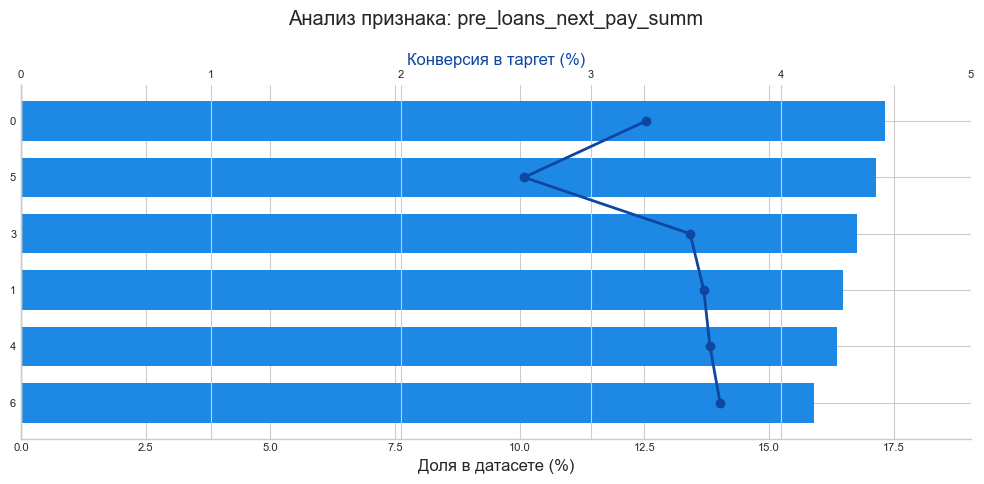

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
0.0                  | 1452141    | 17.3% | 47783      |    3.3%
5.0                  | 1438360    | 17.2% | 38090      |    2.6%
3.0                  | 1406202    | 16.8% | 49525      |    3.5%
1.0                  | 1382525    | 16.5% | 49687      |    3.6%
4.0                  | 1372003    | 16.4% | 49755      |    3.6%
6.0                  | 1334324    | 15.9% | 49101      |    3.7%
-----------------------------------------------------------------
ALL                  | 8385555    | 100.0% | 283941     |    3.4%



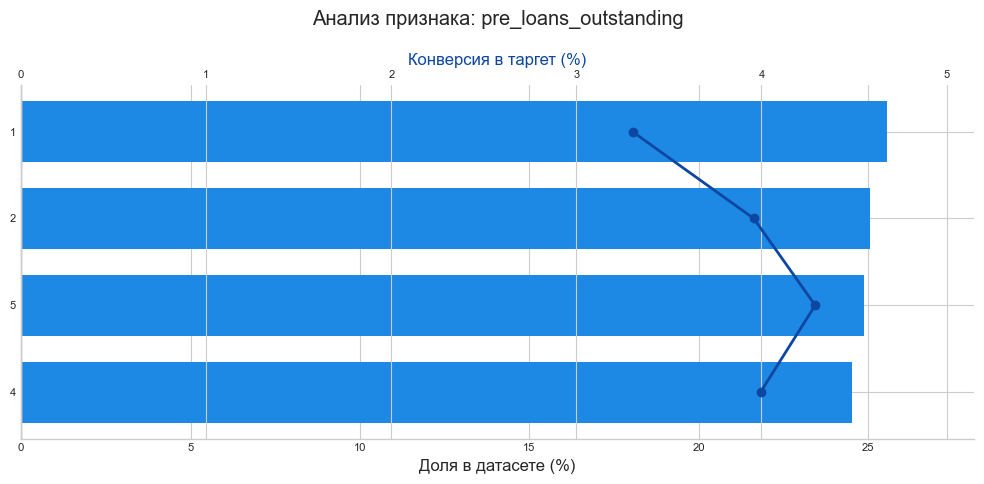

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
1.0                  | 1343015    | 25.6% | 44365      |    3.3%
2.0                  | 1316280    | 25.1% | 52105      |    4.0%
5.0                  | 1306107    | 24.9% | 56036      |    4.3%
4.0                  | 1287845    | 24.5% | 51449      |    4.0%
-----------------------------------------------------------------
ALL                  | 5253247    | 100.0% | 203955     |    3.9%



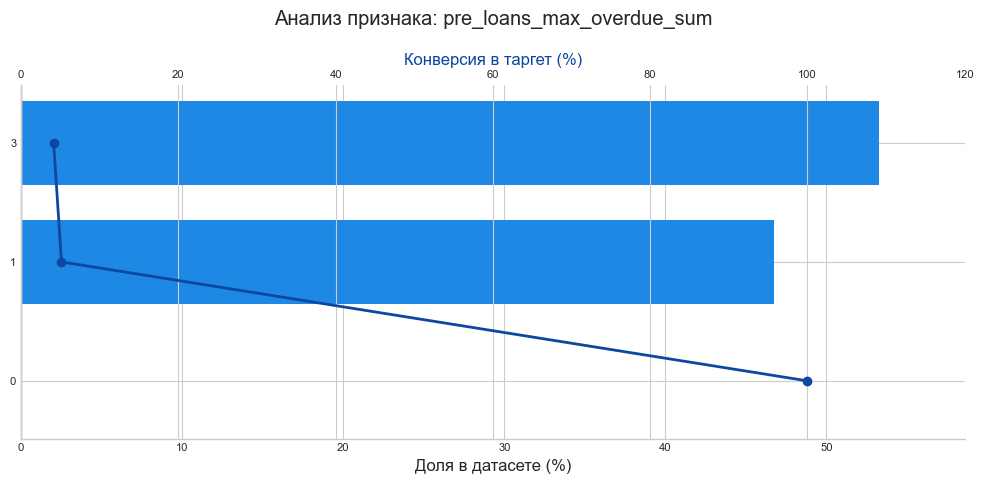

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
3.0                  | 1113827    | 53.3% | 46099      |    4.1%
1.0                  | 977560     | 46.7% | 50178      |    5.1%
0.0                  | 1          |  0.0% | 1          |  100.0%
-----------------------------------------------------------------
ALL                  | 2091388    | 100.0% | 96278      |    4.6%



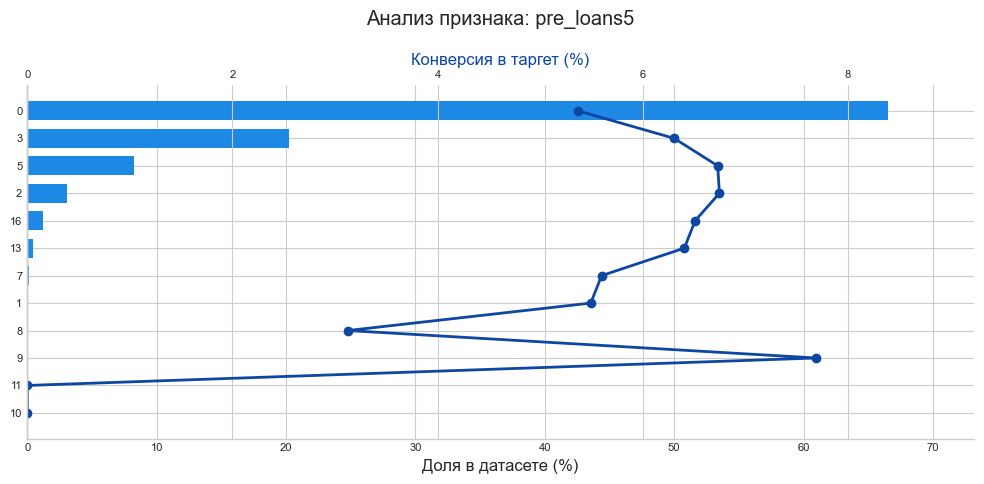

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
0.0                  | 95329      | 66.5% | 5121       |    5.4%
3.0                  | 28998      | 20.2% | 1829       |    6.3%
5.0                  | 11810      |  8.2% | 795        |    6.7%
2.0                  | 4386       |  3.1% | 296        |    6.7%
16.0                 | 1766       |  1.2% | 115        |    6.5%
13.0                 | 640        |  0.4% | 41         |    6.4%
7.0                  | 250        |  0.2% | 14         |    5.6%
1.0                  | 91         |  0.1% | 5          |    5.5%
8.0                  | 32         |  0.0% | 1          |    3.1%
9.0                  | 13         |  0.0% | 1          |    7.7%
11.0                 | 3          |  0.0% | 0          |    0.0%
10.0                 | 1          |  0.0% | 0          |    0.0%
-----------------------------------------------------------------
ALL                  

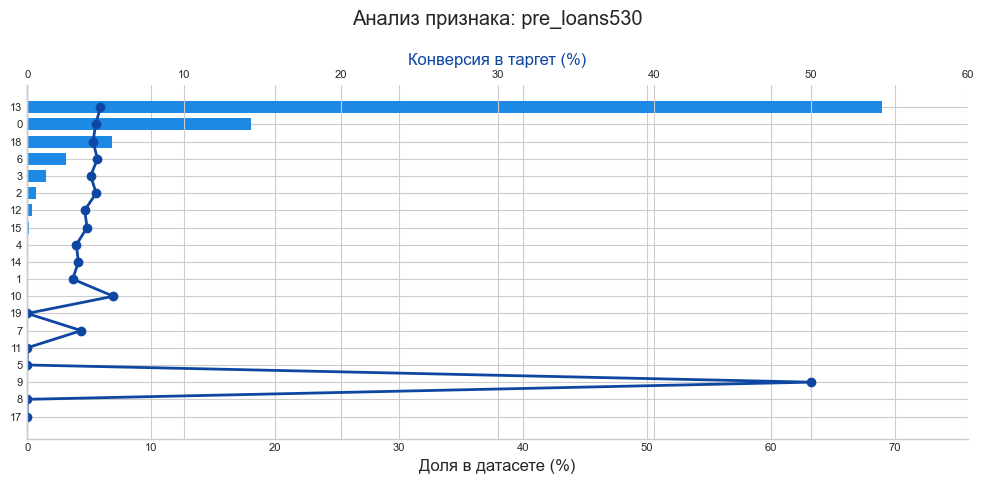

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
13.0                 | 422128     | 69.0% | 19708      |    4.7%
0.0                  | 110507     | 18.1% | 4821       |    4.4%
18.0                 | 42054      |  6.9% | 1766       |    4.2%
6.0                  | 19217      |  3.1% | 860        |    4.5%
3.0                  | 9117       |  1.5% | 369        |    4.0%
2.0                  | 4433       |  0.7% | 195        |    4.4%
12.0                 | 2185       |  0.4% | 80         |    3.7%
15.0                 | 864        |  0.1% | 33         |    3.8%
4.0                  | 575        |  0.1% | 18         |    3.1%
14.0                 | 337        |  0.1% | 11         |    3.3%
1.0                  | 138        |  0.0% | 4          |    2.9%
10.0                 | 91         |  0.0% | 5          |    5.5%
19.0                 | 36         |  0.0% | 0          |    0.0%
7.0                  |

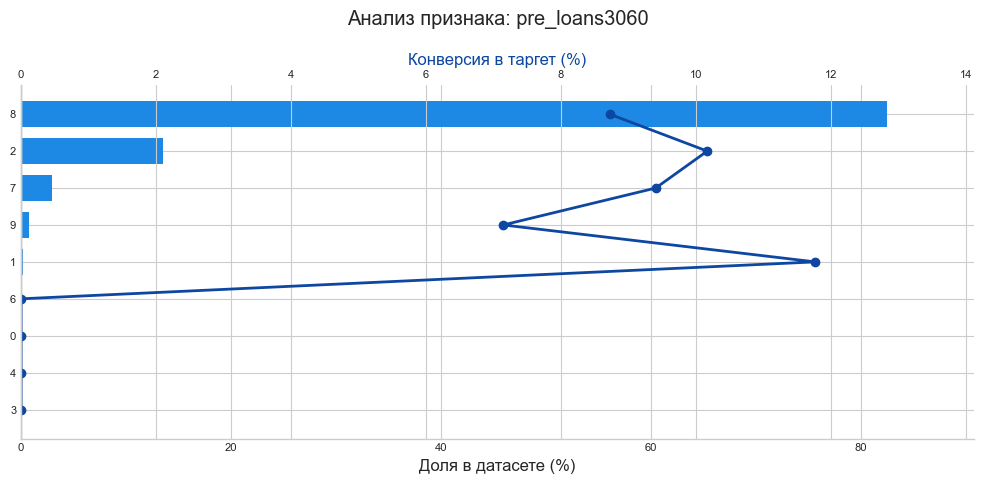

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
8.0                  | 12924      | 82.5% | 1127       |    8.7%
2.0                  | 2115       | 13.5% | 215        |   10.2%
7.0                  | 468        |  3.0% | 44         |    9.4%
9.0                  | 112        |  0.7% | 8          |    7.1%
1.0                  | 34         |  0.2% | 4          |   11.8%
6.0                  | 6          |  0.0% | 0          |    0.0%
0.0                  | 2          |  0.0% | 0          |    0.0%
4.0                  | 1          |  0.0% | 0          |    0.0%
3.0                  | 1          |  0.0% | 0          |    0.0%
-----------------------------------------------------------------
ALL                  | 15663      | 100.0% | 1398       |    8.9%



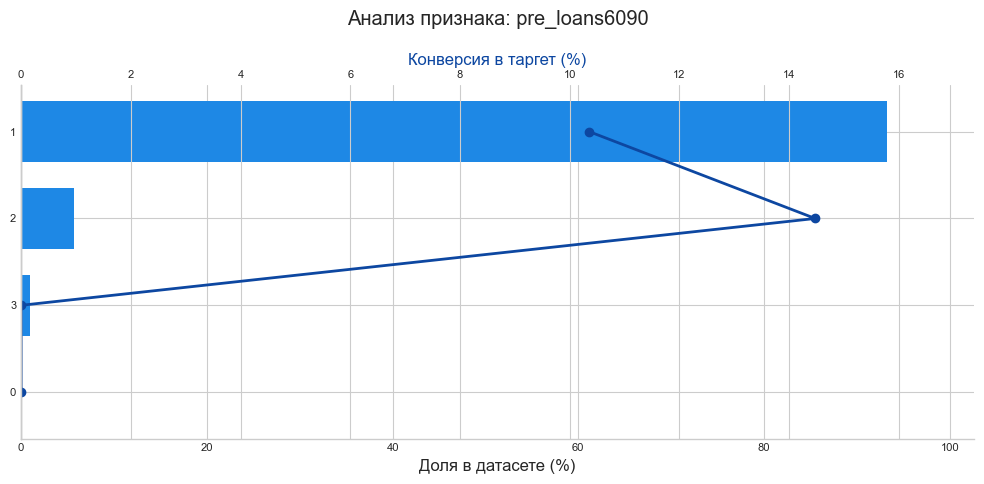

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
1.0                  | 1236       | 93.3% | 128        |   10.4%
2.0                  | 76         |  5.7% | 11         |   14.5%
3.0                  | 12         |  0.9% | 0          |    0.0%
0.0                  | 1          |  0.1% | 0          |    0.0%
-----------------------------------------------------------------
ALL                  | 1325       | 100.0% | 139        |   10.5%



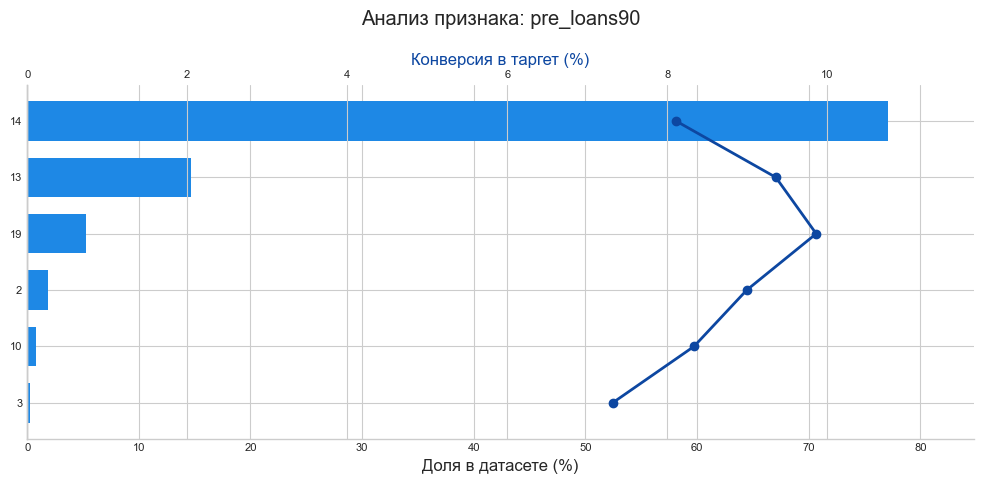

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
14.0                 | 11519      | 77.1% | 934        |    8.1%
13.0                 | 2191       | 14.7% | 205        |    9.4%
19.0                 | 791        |  5.3% | 78         |    9.9%
2.0                  | 278        |  1.9% | 25         |    9.0%
10.0                 | 120        |  0.8% | 10         |    8.3%
3.0                  | 41         |  0.3% | 3          |    7.3%
-----------------------------------------------------------------
ALL                  | 14940      | 100.0% | 1255       |    8.4%



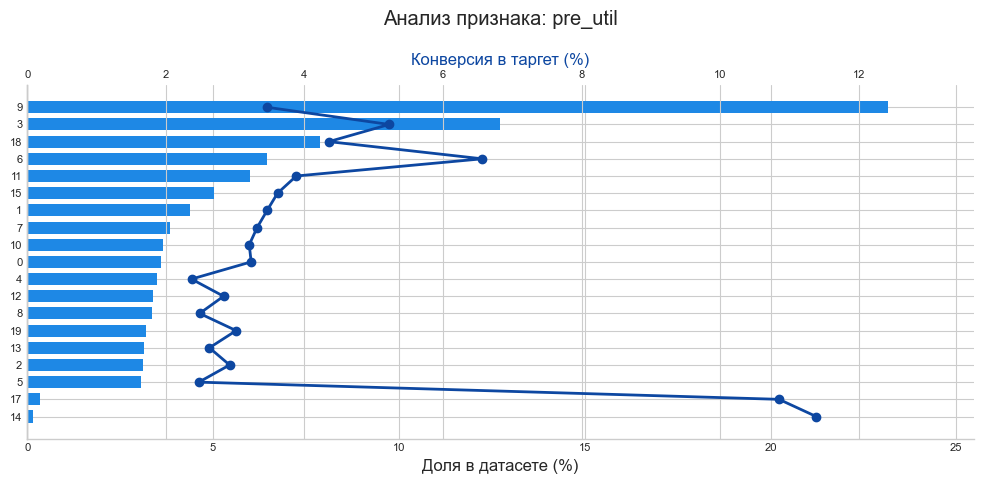

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
9.0                  | 1751629    | 23.2% | 60610      |    3.5%
3.0                  | 962796     | 12.7% | 50289      |    5.2%
18.0                 | 595518     |  7.9% | 25922      |    4.4%
6.0                  | 487768     |  6.4% | 32026      |    6.6%
11.0                 | 453764     |  6.0% | 17622      |    3.9%
15.0                 | 380229     |  5.0% | 13736      |    3.6%
1.0                  | 332213     |  4.4% | 11503      |    3.5%
7.0                  | 289571     |  3.8% | 9608       |    3.3%
10.0                 | 277074     |  3.7% | 8877       |    3.2%
0.0                  | 273076     |  3.6% | 8824       |    3.2%
4.0                  | 264892     |  3.5% | 6280       |    2.4%
12.0                 | 255734     |  3.4% | 7246       |    2.8%
8.0                  | 254544     |  3.4% | 6332       |    2.5%
19.0                 |

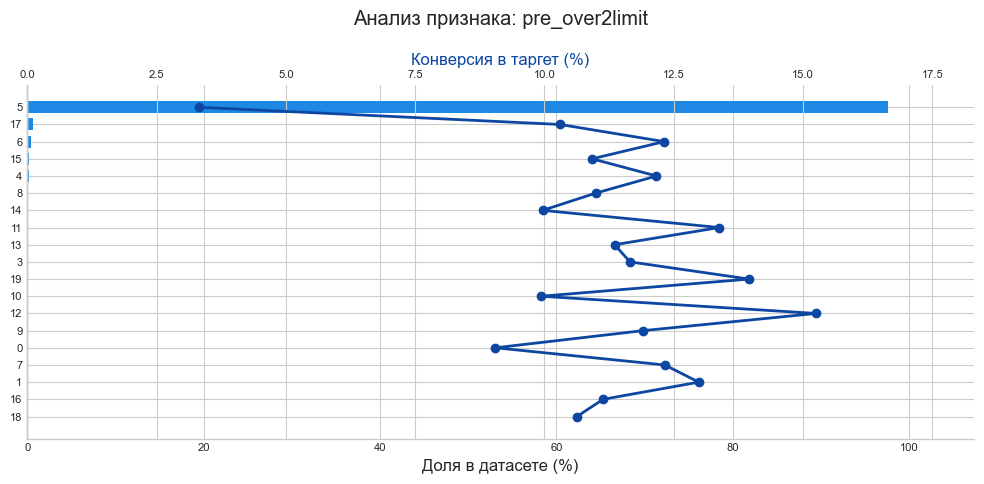

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
5.0                  | 1717063    | 97.6% | 57010      |    3.3%
17.0                 | 12381      |  0.7% | 1275       |   10.3%
6.0                  | 7073       |  0.4% | 871        |   12.3%
15.0                 | 3031       |  0.2% | 331        |   10.9%
4.0                  | 2688       |  0.2% | 327        |   12.2%
8.0                  | 1784       |  0.1% | 196        |   11.0%
14.0                 | 1415       |  0.1% | 141        |   10.0%
11.0                 | 1390       |  0.1% | 186        |   13.4%
13.0                 | 1277       |  0.1% | 145        |   11.4%
3.0                  | 1270       |  0.1% | 148        |   11.7%
19.0                 | 1168       |  0.1% | 163        |   14.0%
10.0                 | 1168       |  0.1% | 116        |    9.9%
12.0                 | 1167       |  0.1% | 178        |   15.3%
9.0                  |

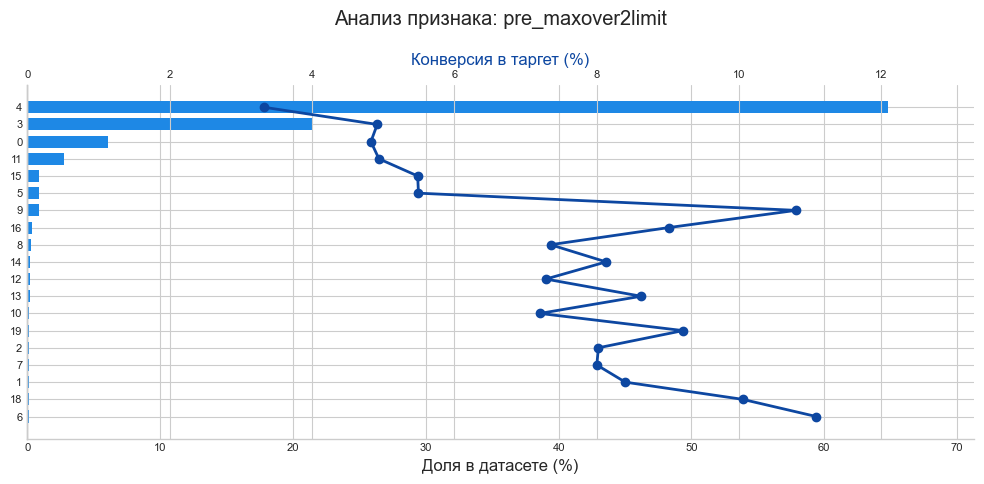

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
4.0                  | 1721548    | 64.8% | 57307      |    3.3%
3.0                  | 571242     | 21.5% | 28097      |    4.9%
0.0                  | 161648     |  6.1% | 7807       |    4.8%
11.0                 | 73027      |  2.7% | 3609       |    4.9%
15.0                 | 24387      |  0.9% | 1338       |    5.5%
5.0                  | 23609      |  0.9% | 1298       |    5.5%
9.0                  | 23511      |  0.9% | 2540       |   10.8%
16.0                 | 9324       |  0.4% | 841        |    9.0%
8.0                  | 6894       |  0.3% | 507        |    7.4%
14.0                 | 5335       |  0.2% | 434        |    8.1%
12.0                 | 4940       |  0.2% | 360        |    7.3%
13.0                 | 4648       |  0.2% | 401        |    8.6%
10.0                 | 4359       |  0.2% | 314        |    7.2%
19.0                 |

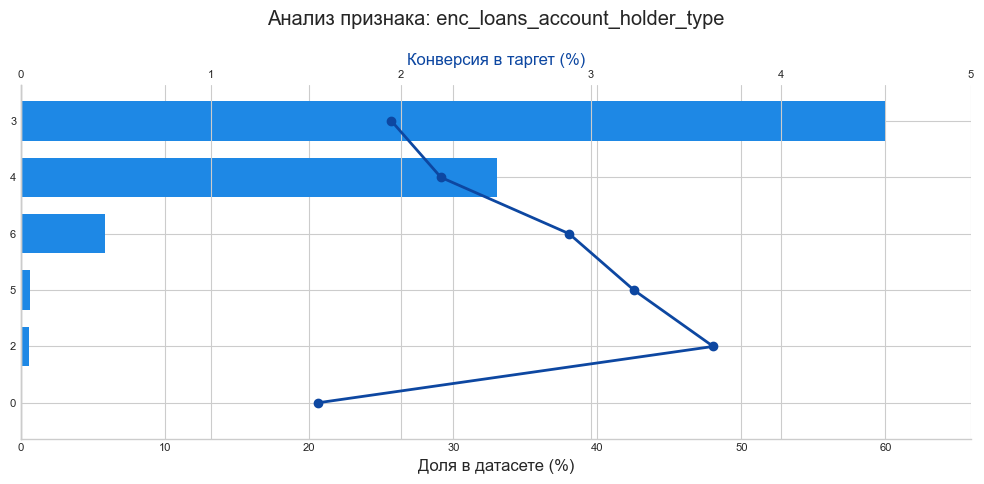

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
3.0                  | 213021     | 59.9% | 4153       |    1.9%
4.0                  | 117422     | 33.0% | 2595       |    2.2%
6.0                  | 20625      |  5.8% | 595        |    2.9%
5.0                  | 2232       |  0.6% | 72         |    3.2%
2.0                  | 2031       |  0.6% | 74         |    3.6%
0.0                  | 64         |  0.0% | 1          |    1.6%
-----------------------------------------------------------------
ALL                  | 355395     | 100.0% | 7490       |    2.1%



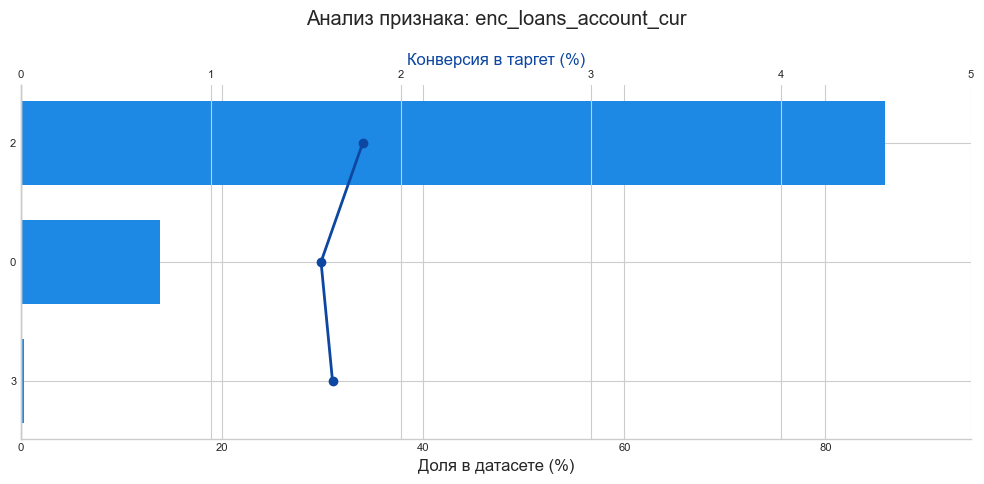

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
2.0                  | 53102      | 85.9% | 955        |    1.8%
0.0                  | 8550       | 13.8% | 135        |    1.6%
3.0                  | 183        |  0.3% | 3          |    1.6%
-----------------------------------------------------------------
ALL                  | 61835      | 100.0% | 1093       |    1.8%



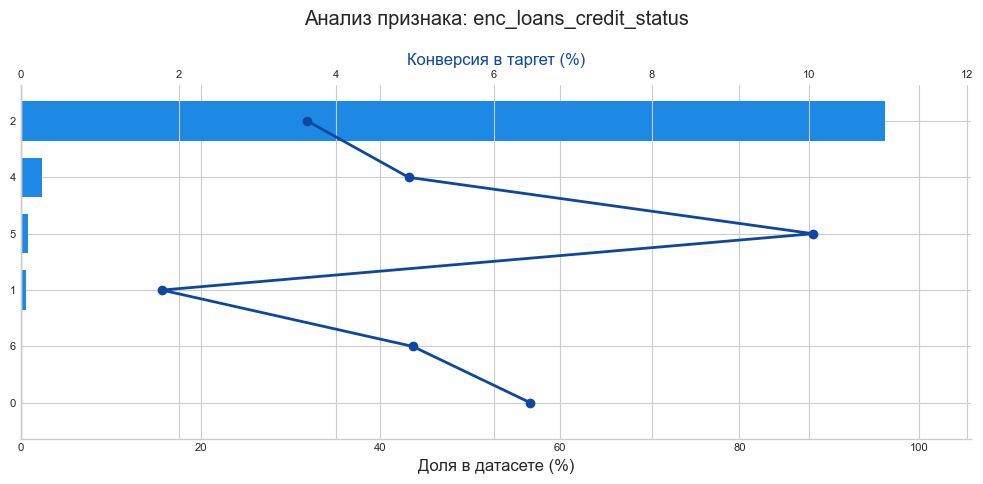

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
2.0                  | 8276203    | 96.2% | 300486     |    3.6%
4.0                  | 201958     |  2.3% | 9930       |    4.9%
5.0                  | 68431      |  0.8% | 6875       |   10.0%
1.0                  | 48568      |  0.6% | 868        |    1.8%
6.0                  | 3803       |  0.0% | 189        |    5.0%
0.0                  | 1981       |  0.0% | 128        |    6.5%
-----------------------------------------------------------------
ALL                  | 8600944    | 100.0% | 318476     |    3.7%



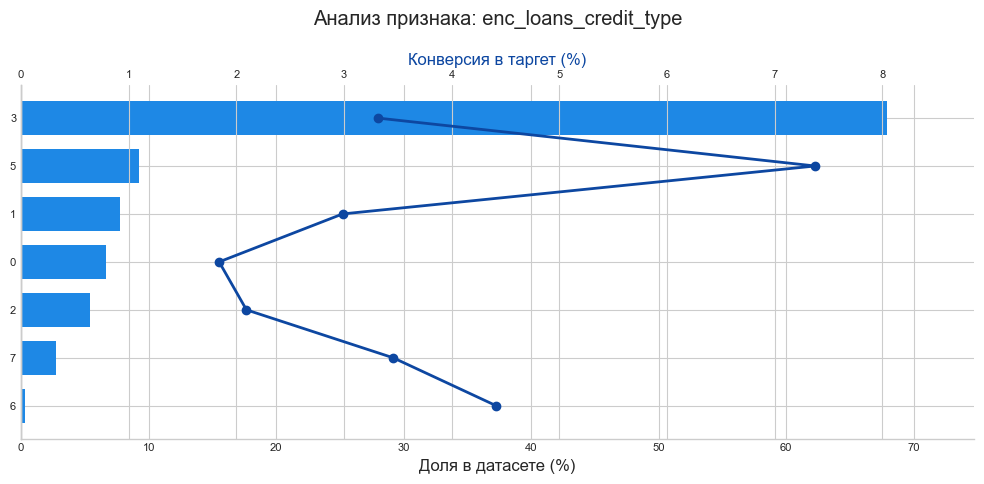

TOP CATEGORIES       | Count      | %      | Target Cnt | Target %
-----------------------------------------------------------------
3.0                  | 7736233    | 67.9% | 256164     |    3.3%
5.0                  | 1050346    |  9.2% | 77464      |    7.4%
1.0                  | 880196     |  7.7% | 26282      |    3.0%
0.0                  | 756480     |  6.6% | 13913      |    1.8%
2.0                  | 617386     |  5.4% | 12921      |    2.1%
7.0                  | 310217     |  2.7% | 10720      |    3.5%
6.0                  | 36873      |  0.3% | 1627       |    4.4%
-----------------------------------------------------------------
ALL                  | 11387731   | 100.0% | 399091     |    3.5%



In [41]:
from src.eda.visualisation import plot_sweetviz_style

# 1. Определяем, что отрезать
exclude_dict = {
    # Сильно выделяющиеся (почти константы или подавляющие бины)
    'pre_loans_next_pay_summ': 2,
    'pre_loans_outstanding': 3,
    'pre_loans_max_overdue_sum': 2,
    'pre_loans5': 6,
    'pre_loans530': 16,
    'pre_loans3060': 5,
    'pre_loans6090': 4,
    'pre_loans90': 8,
    'pre_util': 16,
    'pre_over2limit': 2,
    'pre_maxover2limit': 17,
    'enc_loans_account_holder_type': 1,
    'enc_loans_account_cur': 1,
    
    # Смешанные (доминирует, но есть значимый второй бин)
    'enc_loans_credit_status': 3,
    'enc_loans_credit_type': 4,
}

for feat, dom_bin in exclude_dict.items():
    # 1. Загружаем "узкий" датафрейм специально для этой фичи
    df_single = load_eda_feature_data(cfg, PROJECT_ROOT, feat, dom_bin)
    
    # 2. Визуализируем
    if not df_single.empty:
        plot_sweetviz_style(df_single, feature=feat, target=target_col)
    else:
        print(f"После фильтрации данных для {feat} не осталось.")


# Выводы

## Фичи что подтвердили гипотезу о том, что вне доминатного бина растет конверсия в таргет
- pre_loans3060
- pre_loans5
- pre_loans6090
- pre_loans90
- pre_over2limit
- pre_maxover2limit
- enc_loans_credit_type (5 бин)

Однако имеется проблема, почти все фичи имеют незначительное количетсво объектов разных бинов